# Évaluation des versions du modèle bois/cuivre — accord avec Céline Bohnert

**Projet** : Gallica Images — Classification gravures sur bois vs cuivre

Réutilise les annotations déjà données par Céline Bohnert (désaccords image par
image + accords par titre, dans `retours_celine/`) pour mesurer l'accuracy et la
précision/rappel de la classe cuivre sur les versions successives du modèle
(v1, v2, v3, puis v4.0.0 / v4.1.0 / v4.1.1). C'est l'évaluation de référence du
classifieur bois/cuivre.

**Entrée** : `retours_celine/validation_titres_celine*.csv`, `retours_celine/validation_celine_desaccords_complet.csv`, `resultats/csv/salomon_enrichi_segmente.csv`  
**Sortie** : `resultats/csv/metriques_v1v2v3.csv`, `resultats/csv/metriques_v1v2v3v4.csv`, graphiques dans `resultats/Datavis/`

---

In [2]:
import pandas as pd, os

RACINE = os.path.abspath("../..")
DOSSIER_RETOURS = os.path.join(RACINE, "retours_celine")

# ── 1. Charger les deux fichiers tels quels ─────────────────
t1 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine.csv"),
                 engine="python", on_bad_lines="skip")
t2 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine_complet.csv"),
                 engine="python", on_bad_lines="skip")

print(f"validation_titres_celine          : {len(t1)} titres")
print(f"validation_titres_celine_complet  : {len(t2)} titres")

# ── 2. Combiner directement (pas de filtrage) ───────────────
combine = pd.concat([t1, t2], ignore_index=True)
print(f"  → total combiné : {len(combine)} titres\n")

# ── 3. Ne garder que les titres réellement annotés ──────────
combine["avis_celine"] = combine["avis_celine"].astype(str).str.strip().str.lower()
annotes = combine[combine["avis_celine"].isin(["valide", "invalide"])].copy()
print(f"Titres annotés (non vides) : {len(annotes)}")
print(f"  Vides exclus : {len(combine) - len(annotes)}\n")

# ── 4. Statistiques ─────────────────────────────────────────
print("=" * 50)
print("VALIDATION DES TITRES CLASSÉS CUIVRE (accord v1+v2+v3)")
print("=" * 50)
n_valide   = (annotes["avis_celine"] == "valide").sum()
n_invalide = (annotes["avis_celine"] == "invalide").sum()
total      = n_valide + n_invalide

print(f"  Total titres annotés : {total}")
print(f"  ✓ Corrects (valide)  : {n_valide} ({n_valide/total:.1%})")
print(f"  ✗ Incorrects         : {n_invalide} ({n_invalide/total:.1%})")

# Pondéré par nombre d'illustrations
if "nb_illustrations" in annotes.columns:
    annotes["nb_illustrations"] = pd.to_numeric(annotes["nb_illustrations"], errors="coerce").fillna(0)
    iv = annotes[annotes["avis_celine"]=="valide"]["nb_illustrations"].sum()
    ii = annotes[annotes["avis_celine"]=="invalide"]["nb_illustrations"].sum()
    it = iv + ii
    print(f"\n  En illustrations :")
    print(f"    ✓ Corrects   : {int(iv)} ({iv/it:.1%})")
    print(f"    ✗ Incorrects : {int(ii)} ({ii/it:.1%})")

# ── 5. Titres incorrects ────────────────────────────────────
if n_invalide > 0:
    print("\n" + "=" * 50)
    print("TITRES JUGÉS INCORRECTS")
    print("=" * 50)
    for _, row in annotes[annotes["avis_celine"]=="invalide"].iterrows():
        comm = row.get("commentaire", "")
        comm = f" — {comm}" if pd.notna(comm) and str(comm).strip() else ""
        print(f"  • {row['titre'][:70]}{comm}")

validation_titres_celine          : 118 titres
validation_titres_celine_complet  : 11 titres
  → total combiné : 129 titres

Titres annotés (non vides) : 116
  Vides exclus : 13

VALIDATION DES TITRES CLASSÉS CUIVRE (accord v1+v2+v3)
  Total titres annotés : 116
  ✓ Corrects (valide)  : 110 (94.8%)
  ✗ Incorrects         : 6 (5.2%)

  En illustrations :
    ✓ Corrects   : 432 (94.1%)
    ✗ Incorrects : 27 (5.9%)

TITRES JUGÉS INCORRECTS
  • [Illustrations de Cosmographie universelle] / [Non identifié] ; André 
  • [Illustrations de Les Métamorphoses] / [Non identifié] ; Ovide, aut. d — iconographie super pertinente ! 
  • [Illustrations de De Re mtallica libri XII. ..] / [Non identifié] ; Ge
  • [L'Apocalypse]. 15, [La Grande prostituée de Babylone, édition latine 
  • [Illustrations de Orlando furioso] / [Non identifié] ; Ludovico Ariost
  • [Illustrations de Les Métamorphoses] / Georges Wickram, grav. ; Ovide,


In [4]:
t1 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine.csv"),
                 engine="python", on_bad_lines="skip")
t2 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine_complet.csv"),
                 engine="python", on_bad_lines="skip")

# Combiner, en privilégiant le fichier complet pour les titres présents dans les deux
combine = pd.concat([t2, t1], ignore_index=True)
combine = combine.drop_duplicates(subset=["titre"], keep="first")  # garde la version de t2
print(f"Titres uniques combinés : {len(combine)}")

# Normaliser
combine["avis_celine"]  = combine["avis_celine"].astype(str).str.strip().str.lower()
combine["commentaire"]  = combine["commentaire"].astype(str).fillna("")

# Marquer les douteux (?? dans le commentaire)
combine["douteux"] = combine["commentaire"].str.contains(r"\?\?", regex=True, na=False)

# Garder seulement valide/invalide ET non douteux
annotes = combine[
    combine["avis_celine"].isin(["valide", "invalide"]) &
    (~combine["douteux"])
].copy()

print(f"Titres annotés fermes (hors ?? et vides) : {len(annotes)}")
print(f"  Exclus (vides ou douteux) : {len(combine) - len(annotes)}\n")

# ── Statistiques ────────────────────────────────────────────
n_valide   = (annotes["avis_celine"] == "valide").sum()
n_invalide = (annotes["avis_celine"] == "invalide").sum()
total      = n_valide + n_invalide

print("=" * 50)
print("VALIDATION TITRES CUIVRE (accord v1+v2+v3) — avis fermes")
print("=" * 50)
print(f"  Total titres fermes : {total}")
print(f"  ✓ Corrects   : {n_valide} ({n_valide/total:.1%})")
print(f"  ✗ Incorrects : {n_invalide} ({n_invalide/total:.1%})")

annotes["nb_illustrations"] = pd.to_numeric(annotes["nb_illustrations"], errors="coerce").fillna(0)
iv = annotes[annotes["avis_celine"]=="valide"]["nb_illustrations"].sum()
ii = annotes[annotes["avis_celine"]=="invalide"]["nb_illustrations"].sum()
print(f"\n  En illustrations :")
print(f"    ✓ Corrects   : {int(iv)} ({iv/(iv+ii):.1%})")
print(f"    ✗ Incorrects : {int(ii)} ({ii/(iv+ii):.1%})")

print("\n  Titres jugés incorrects :")
for _, r in annotes[annotes["avis_celine"]=="invalide"].iterrows():
    print(f"    • {r['titre'][:65]}")

Titres uniques combinés : 120
Titres annotés fermes (hors ?? et vides) : 103
  Exclus (vides ou douteux) : 17

VALIDATION TITRES CUIVRE (accord v1+v2+v3) — avis fermes
  Total titres fermes : 103
  ✓ Corrects   : 98 (95.1%)
  ✗ Incorrects : 5 (4.9%)

  En illustrations :
    ✓ Corrects   : 328 (92.9%)
    ✗ Incorrects : 25 (7.1%)

  Titres jugés incorrects :
    • [Illustrations de Orlando furioso] / [Non identifié] ; Ludovico A
    • [Illustrations de Les Métamorphoses] / Georges Wickram, grav. ; O
    • [Illustrations de Les Métamorphoses] / [Non identifié] ; Ovide, a
    • [Illustrations de De Re mtallica libri XII. ..] / [Non identifié]
    • [L'Apocalypse]. 15, [La Grande prostituée de Babylone, édition la


In [5]:
t1 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine.csv"),
                 engine="python", on_bad_lines="skip")
t2 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine_complet.csv"),
                 engine="python", on_bad_lines="skip")

combine = pd.concat([t1, t2], ignore_index=True)
combine["nb_illustrations"] = pd.to_numeric(combine["nb_illustrations"], errors="coerce").fillna(0)

# Trier par nb_illustrations décroissant puis garder la 1re occurrence de chaque titre
# → on conserve la version avec le PLUS GRAND nombre d'illustrations
combine = (combine.sort_values("nb_illustrations", ascending=False)
                  .drop_duplicates(subset=["titre"], keep="first")
                  .reset_index(drop=True))
print(f"Titres uniques combinés : {len(combine)}")

# Normaliser
combine["avis_celine"] = combine["avis_celine"].astype(str).str.strip().str.lower()
combine["commentaire"] = combine["commentaire"].astype(str).fillna("")
combine["douteux"]     = combine["commentaire"].str.contains(r"\?\?", regex=True, na=False)

annotes = combine[
    combine["avis_celine"].isin(["valide", "invalide"]) &
    (~combine["douteux"])
].copy()

print(f"Titres annotés fermes (hors ?? et vides) : {len(annotes)}")
print(f"  Exclus (vides ou douteux) : {len(combine) - len(annotes)}\n")

# ── Statistiques ────────────────────────────────────────────
n_valide   = (annotes["avis_celine"] == "valide").sum()
n_invalide = (annotes["avis_celine"] == "invalide").sum()
total      = n_valide + n_invalide

print("=" * 50)
print("VALIDATION TITRES CUIVRE (accord v1+v2+v3) — avis fermes")
print("=" * 50)
print(f"  Total titres fermes : {total}")
print(f"  ✓ Corrects   : {n_valide} ({n_valide/total:.1%})")
print(f"  ✗ Incorrects : {n_invalide} ({n_invalide/total:.1%})")

iv = annotes[annotes["avis_celine"]=="valide"]["nb_illustrations"].sum()
ii = annotes[annotes["avis_celine"]=="invalide"]["nb_illustrations"].sum()
print(f"\n  En illustrations :")
print(f"    ✓ Corrects   : {int(iv)} ({iv/(iv+ii):.1%})")
print(f"    ✗ Incorrects : {int(ii)} ({ii/(iv+ii):.1%})")

print("\n  Titres jugés incorrects :")
for _, r in annotes[annotes["avis_celine"]=="invalide"].iterrows():
    print(f"    • {r['titre'][:65]} ({int(r['nb_illustrations'])} illustr.)")

Titres uniques combinés : 120
Titres annotés fermes (hors ?? et vides) : 103
  Exclus (vides ou douteux) : 17

VALIDATION TITRES CUIVRE (accord v1+v2+v3) — avis fermes
  Total titres fermes : 103
  ✓ Corrects   : 98 (95.1%)
  ✗ Incorrects : 5 (4.9%)

  En illustrations :
    ✓ Corrects   : 328 (92.9%)
    ✗ Incorrects : 25 (7.1%)

  Titres jugés incorrects :
    • [Illustrations de Orlando furioso] / [Non identifié] ; Ludovico A (17 illustr.)
    • [Illustrations de Les Métamorphoses] / Georges Wickram, grav. ; O (5 illustr.)
    • [Illustrations de Les Métamorphoses] / [Non identifié] ; Ovide, a (1 illustr.)
    • [Illustrations de De Re mtallica libri XII. ..] / [Non identifié] (1 illustr.)
    • [L'Apocalypse]. 15, [La Grande prostituée de Babylone, édition la (1 illustr.)


In [6]:
# ── Charger les annotations de désaccords ───────────────────
des = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_celine_desaccords_complet.csv"))
des = des[des["avis_celine"].isin(["bois", "cuivre"])].copy()

n = len(des)
print("=" * 55)
print(f"STATS DÉSACCORDS — {n} illustrations annotées par Céline")
print("=" * 55)
print(f"Répartition réelle (avis Céline) : "
      f"{(des['avis_celine']=='cuivre').sum()} cuivre, "
      f"{(des['avis_celine']=='bois').sum()} bois\n")

# ── 1. Accuracy par version ─────────────────────────────────
print("ACCURACY DE CHAQUE VERSION")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    c = (des[v] == des["avis_celine"]).sum()
    print(f"  {v} : {c/n:.1%}  ({c}/{n})")

# ── 2. Qui tranche juste sur les désaccords ─────────────────
for v in ["v1", "v2", "v3"]:
    des[f"{v}_ok"] = des[v] == des["avis_celine"]

seuls = {
    "v1": des[des["v1_ok"] & ~des["v2_ok"] & ~des["v3_ok"]],
    "v2": des[des["v2_ok"] & ~des["v1_ok"] & ~des["v3_ok"]],
    "v3": des[des["v3_ok"] & ~des["v1_ok"] & ~des["v2_ok"]],
}
print("\nQUI A RAISON QUAND ELLE EST SEULE À TRANCHER")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    print(f"  {v} seule a raison : {len(seuls[v])}")

# ── 3. Nature des erreurs ───────────────────────────────────
print("\nNATURE DES ERREURS")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    err = des[des[v] != des["avis_celine"]]
    rates = len(err[(err[v]=="bois") & (err["avis_celine"]=="cuivre")])
    faux  = len(err[(err[v]=="cuivre") & (err["avis_celine"]=="bois")])
    print(f"  {v} — {len(err)} erreurs : {rates} cuivres ratés, {faux} faux cuivres")

STATS DÉSACCORDS — 319 illustrations annotées par Céline
Répartition réelle (avis Céline) : 193 cuivre, 126 bois

ACCURACY DE CHAQUE VERSION
-------------------------------------------------------
  v1 : 59.9%  (191/319)
  v2 : 49.2%  (157/319)
  v3 : 60.2%  (192/319)

QUI A RAISON QUAND ELLE EST SEULE À TRANCHER
-------------------------------------------------------
  v1 seule a raison : 10
  v2 seule a raison : 17
  v3 seule a raison : 69

NATURE DES ERREURS
-------------------------------------------------------
  v1 — 128 erreurs : 112 cuivres ratés, 14 faux cuivres
  v2 — 162 erreurs : 148 cuivres ratés, 11 faux cuivres
  v3 — 127 erreurs : 9 cuivres ratés, 116 faux cuivres


In [7]:
RACINE = os.path.abspath("../..")
des = pd.read_csv(os.path.join(RACINE, "retours_celine", "validation_celine_desaccords_complet.csv"))
des = des[des["avis_celine"].isin(["bois", "cuivre"])].copy()
n = len(des)

print("=" * 55)
print(f"STATS DÉSACCORDS — {n} illustrations annotées par Céline")
print("=" * 55)
print(f"Répartition réelle (avis Céline) : "
      f"{(des.avis_celine=='cuivre').sum()} cuivre, {(des.avis_celine=='bois').sum()} bois\n")

print("ACCURACY DE CHAQUE VERSION")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    c = (des[v] == des.avis_celine).sum()
    print(f"  {v} : {c/n:.1%}  ({c}/{n})")

print("\nCUIVRE DÉTECTÉ ET PRÉCISION (sur les désaccords)")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    det  = (des[v] == "cuivre").sum()
    vrai = ((des[v] == "cuivre") & (des.avis_celine == "cuivre")).sum()
    print(f"  {v} : {det} cuivres détectés, {vrai} validés vrais ({vrai/det:.1%})")

STATS DÉSACCORDS — 319 illustrations annotées par Céline
Répartition réelle (avis Céline) : 193 cuivre, 126 bois

ACCURACY DE CHAQUE VERSION
-------------------------------------------------------
  v1 : 59.9%  (191/319)
  v2 : 49.2%  (157/319)
  v3 : 60.2%  (192/319)

CUIVRE DÉTECTÉ ET PRÉCISION (sur les désaccords)
-------------------------------------------------------
  v1 : 95 cuivres détectés, 81 validés vrais (85.3%)
  v2 : 56 cuivres détectés, 45 validés vrais (80.4%)
  v3 : 298 cuivres détectés, 182 validés vrais (61.1%)


In [10]:
# ===== 1. DÉSACCORDS (avis par illustration) =====
des = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_celine_desaccords_complet.csv"))
des = des[des["avis_celine"].isin(["bois", "cuivre"])].copy()
n = len(des)

print("=" * 55)
print(f"STATS DÉSACCORDS — {n} illustrations annotées")
print("=" * 55)
print(f"Répartition réelle : "
      f"{(des.avis_celine=='cuivre').sum()} cuivre, {(des.avis_celine=='bois').sum()} bois\n")

print("ACCURACY DE CHAQUE VERSION")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    c = (des[v] == des.avis_celine).sum()
    print(f"  {v} : {c/n:.1%}  ({c}/{n})")

print("\nCUIVRE DÉTECTÉ ET PRÉCISION (sur les désaccords)")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    det  = (des[v] == "cuivre").sum()
    vrai = ((des[v] == "cuivre") & (des.avis_celine == "cuivre")).sum()
    print(f"  {v} : {det} cuivres détectés, {vrai} validés vrais ({vrai/det:.1%})")

# ===== 2. ACCORDS (par titre, avis fermes, pondéré nb_illustrations) =====
t1 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine.csv"),
                 engine="python", on_bad_lines="skip")
t2 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine_complet.csv"),
                 engine="python", on_bad_lines="skip")
tit = pd.concat([t1, t2], ignore_index=True)
tit["nb_illustrations"] = pd.to_numeric(tit["nb_illustrations"], errors="coerce").fillna(0)
tit = tit.sort_values("nb_illustrations", ascending=False).drop_duplicates("titre", keep="first")
tit["avis_celine"] = tit["avis_celine"].astype(str).str.strip().str.lower()
tit["douteux"] = tit["commentaire"].astype(str).str.contains(r"\?\?", regex=True, na=False)
tit = tit[tit["avis_celine"].isin(["valide", "invalide"]) & ~tit["douteux"]]
acc_vrai  = tit[tit.avis_celine == "valide"]["nb_illustrations"].sum()
acc_total = tit["nb_illustrations"].sum()

# ===== 3. PRÉCISION CUIVRE GLOBALE (désaccords + accords) =====
print("\n" + "=" * 55)
print("PRÉCISION CUIVRE GLOBALE (désaccords + accords)")
print("=" * 55)
print(f"  (accords communs aux 3 versions : {int(acc_vrai)}/{int(acc_total)} vrais)")
print("-" * 55)
for v in ["v1", "v2", "v3"]:
    d_det  = (des[v] == "cuivre").sum()
    d_vrai = ((des[v] == "cuivre") & (des.avis_celine == "cuivre")).sum()
    g_vrai = d_vrai + acc_vrai
    g_det  = d_det + acc_total
    print(f"  {v} : {int(g_vrai)}/{int(g_det)} vrais cuivres ({g_vrai/g_det:.1%})")

STATS DÉSACCORDS — 319 illustrations annotées
Répartition réelle : 193 cuivre, 126 bois

ACCURACY DE CHAQUE VERSION
-------------------------------------------------------
  v1 : 59.9%  (191/319)
  v2 : 49.2%  (157/319)
  v3 : 60.2%  (192/319)

CUIVRE DÉTECTÉ ET PRÉCISION (sur les désaccords)
-------------------------------------------------------
  v1 : 95 cuivres détectés, 81 validés vrais (85.3%)
  v2 : 56 cuivres détectés, 45 validés vrais (80.4%)
  v3 : 298 cuivres détectés, 182 validés vrais (61.1%)

PRÉCISION CUIVRE GLOBALE (désaccords + accords)
  (accords communs aux 3 versions : 328/353 vrais)
-------------------------------------------------------
  v1 : 409/448 vrais cuivres (91.3%)
  v2 : 373/409 vrais cuivres (91.2%)
  v3 : 510/651 vrais cuivres (78.3%)


Version  Accuracy_désaccords  Précision  Rappel    F1  Vrais_cuivres  Détectés_cuivre
     V1                0.599      0.913   0.785 0.844            409              448
     V2                0.492      0.912   0.716 0.802            373              409
     V3                0.602      0.783   0.979 0.870            510              651

✓ Tableau sauvegardé : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/resultats/csv/metriques_v1v2v3.csv


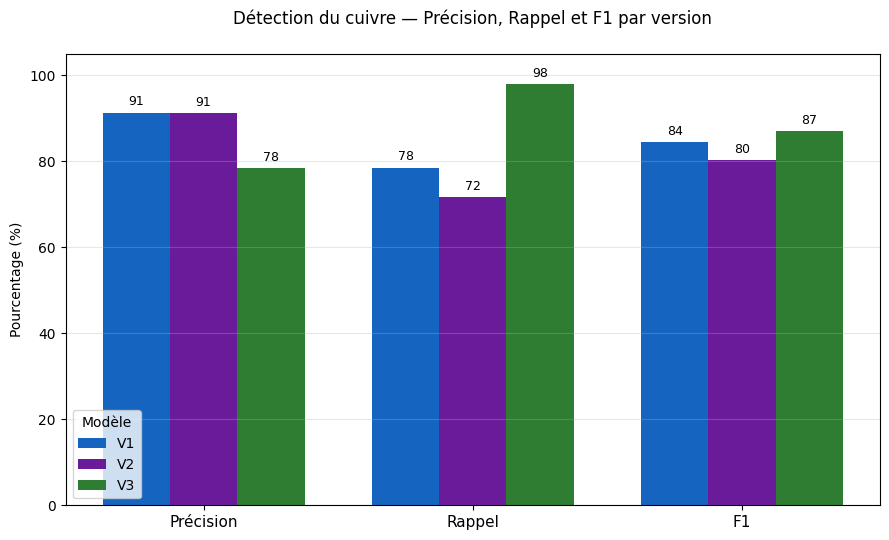

✓ Graphique sauvegardé : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/resultats/visualisations/metriques_v1v2v3.png


In [12]:
import pandas as pd, os
import matplotlib.pyplot as plt
import numpy as np

RACINE = os.path.abspath("../..")
DOSSIER_RETOURS = os.path.join(RACINE, "retours_celine")
DOSSIER_VIZ     = os.path.join(RACINE, "resultats", "Datavis")
os.makedirs(DOSSIER_VIZ, exist_ok=True)

# ===== Recalcul des métriques =====
des = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_celine_desaccords_complet.csv"))
des = des[des["avis_celine"].isin(["bois", "cuivre"])].copy()

t1 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine.csv"),
                 engine="python", on_bad_lines="skip")
t2 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine_complet.csv"),
                 engine="python", on_bad_lines="skip")
tit = pd.concat([t1, t2], ignore_index=True)
tit["nb_illustrations"] = pd.to_numeric(tit["nb_illustrations"], errors="coerce").fillna(0)
tit = tit.sort_values("nb_illustrations", ascending=False).drop_duplicates("titre", keep="first")
tit["avis_celine"] = tit["avis_celine"].astype(str).str.strip().str.lower()
tit["douteux"] = tit["commentaire"].astype(str).str.contains(r"\?\?", regex=True, na=False)
tit = tit[tit["avis_celine"].isin(["valide", "invalide"]) & ~tit["douteux"]]
acc_vrai = tit[tit.avis_celine == "valide"]["nb_illustrations"].sum()
acc_tot  = tit["nb_illustrations"].sum()
total_vrais = (des.avis_celine == "cuivre").sum() + acc_vrai

rows = []
for v in ["v1", "v2", "v3"]:
    n = len(des)
    acc = (des[v] == des.avis_celine).sum() / n
    d_vrai = ((des[v] == "cuivre") & (des.avis_celine == "cuivre")).sum()
    retr = d_vrai + acc_vrai
    det  = (des[v] == "cuivre").sum() + acc_tot
    prec = retr / det
    rapp = retr / total_vrais
    f1   = 2 * prec * rapp / (prec + rapp)
    rows.append({
        "Version": v.upper(),
        "Accuracy_désaccords": round(acc, 3),
        "Précision": round(prec, 3),
        "Rappel": round(rapp, 3),
        "F1": round(f1, 3),
        "Vrais_cuivres": int(retr),
        "Détectés_cuivre": int(det),
    })

recap = pd.DataFrame(rows)
print(recap.to_string(index=False))

# ===== Sauvegarder le tableau en CSV =====
chemin_csv = os.path.join(RACINE, "resultats", "csv", "metriques_v1v2v3.csv")
recap.to_csv(chemin_csv, index=False, encoding="utf-8-sig")
print(f"\n✓ Tableau sauvegardé : {chemin_csv}")

# ===== Graphique en barres groupées =====
fig, ax = plt.subplots(figsize=(9, 5.5))
metriques = ["Précision", "Rappel", "F1"]
x = np.arange(len(metriques))
largeur = 0.25
couleurs = {"V1": "#1565c0", "V2": "#6a1b9a", "V3": "#2e7d32"}

for i, v in enumerate(["V1", "V2", "V3"]):
    valeurs = [recap[recap.Version == v][m].values[0] * 100 for m in metriques]
    barres = ax.bar(x + (i - 1) * largeur, valeurs, largeur,
                    label=v, color=couleurs[v])
    for b, val in zip(barres, valeurs):
        ax.text(b.get_x() + b.get_width()/2, val + 1, f"{val:.0f}",
                ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Pourcentage (%)")
ax.set_title("Détection du cuivre — Précision, Rappel et F1 par version\n"
            , fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metriques, fontsize=11)
ax.set_ylim(0, 105)
ax.legend(title="Modèle")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

chemin_png = os.path.join(DOSSIER_VIZ, "metriques_v1v2v3.png")
plt.savefig(chemin_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Graphique sauvegardé : {chemin_png}")

In [16]:
# ══════════════════════════════════════════════════════════════════
# ÉVALUATION DE v4.0.0 / v4.1.0 / v4.1.1 — RÉUTILISE LES AVIS DÉJÀ DONNÉS PAR CÉLINE
# ══════════════════════════════════════════════════════════════════
#
# Principe : les fichiers retours_celine/ contiennent déjà, par IMAGE
# (désaccords) et par TITRE (accords v1+v2+v3=cuivre), le jugement de
# Céline. On ne lui redemande rien — on applique juste v4.0.0/v4.1.0/v4.1.1
# aux mêmes images et on compare aux mêmes avis.

import pandas as pd, os, sys

RACINE = os.path.abspath("../..")
sys.path.insert(0, os.path.join(RACINE, "notebooks"))
from gallica_utils import charger_resnet, predire_technique

DOSSIER_MODELES = os.path.join(RACINE, "modeles", "bois_cuivre")
DOSSIER_RETOURS = os.path.join(RACINE, "retours_celine")

fichiers_modeles_v4 = {
    "v4.0.0": "resnet50_bois_cuivre_v4.0.0.pth",
    "v4.1.0": "resnet50_bois_cuivre_v4.1.0.pth",
    "v4.1.1": "resnet50_bois_cuivre_v4.1.1.pth",
}
modeles_v4 = {
    v: charger_resnet(os.path.join(DOSSIER_MODELES, nom))
    for v, nom in fichiers_modeles_v4.items()
}
VERSIONS_V4 = list(fichiers_modeles_v4.keys())

✓ ResNet50 chargé : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/modeles/bois_cuivre/resnet50_bois_cuivre_v4.0.0.pth
✓ ResNet50 chargé : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/modeles/bois_cuivre/resnet50_bois_cuivre_v4.1.0.pth
✓ ResNet50 chargé : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/modeles/bois_cuivre/resnet50_bois_cuivre_v4.1.1.pth


In [17]:
# ── Désaccords (319 images) — retrouver le lien exact de chaque image ──
# validation_celine_desaccords_complet.csv n'a que ark+folio (la page),
# pas le recadrage précis de l'illustration. On le retrouve en recroisant
# avec salomon_enrichi_segmente.csv (qui a le lien complet avec recadrage)
# via ark+folio+titre+v1+v2+v3 — résout 317/319 lignes sans ambiguïté
# (2 lignes ont plusieurs recadrages candidats identiques sur ces critères ;
# on garde le premier, marge d'erreur négligeable sur 319).

des = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_celine_desaccords_complet.csv"))
des = des[des["avis_celine"].isin(["bois", "cuivre"])].reset_index(drop=True)
des["row_id"] = des.index

df_sal = pd.read_csv(os.path.join(RACINE, "resultats", "csv", "salomon_enrichi_segmente.csv"))
df_sal["ark_parsed"]   = df_sal["link"].str.extract(r"ark:/12148/(\w+)")
df_sal["folio_parsed"] = df_sal["link"].str.extract(r"/(f\d+)/")

jointure = des.merge(
    df_sal, left_on=["ark", "folio", "titre", "v1", "v2", "v3"],
    right_on=["ark_parsed", "folio_parsed", "titre", "technique_ia_v1", "technique_ia_v2", "technique_ia_v3"],
    how="left"
)
liens = jointure.groupby("row_id")["link"].first()
des["link"] = des["row_id"].map(liens)

print(f"Désaccords : {len(des)} lignes, {des['link'].isna().sum()} sans lien retrouvé")

Désaccords : 319 lignes, 0 sans lien retrouvé


In [18]:
# ── Prédiction v4.0.0 / v4.1.0 / v4.1.1 sur les 319 désaccords ──
print("Prédiction en cours (désaccords)...")
for i, row in des.iterrows():
    if pd.isna(row["link"]):
        continue
    for v, modele in modeles_v4.items():
        classe, conf = predire_technique(row["link"], modele)
        des.loc[i, v]          = classe
        des.loc[i, f"conf_{v}"] = conf
    print(f"  {i + 1}/{len(des)}", end="\r")
print(f"\n✓ Désaccords classés par {VERSIONS_V4}")

# Denominateur commun — exclut toute image "inconnu" pour au moins une
# version (v1/v2/v3 compris), pour que toutes les versions soient comparees
# sur exactement le meme ensemble d'images (evite qu'un simple echec de
# telechargement reseau sur une version fasse bouger les chiffres).
colonnes_versions = ["v1", "v2", "v3"] + VERSIONS_V4
avant = len(des)
des = des[(des[colonnes_versions] != "inconnu").all(axis=1)].reset_index(drop=True)
print(f"Images retirees (inconnu pour au moins une version) : {avant - len(des)} / {avant}")

n = len(des)
print("\n" + "=" * 55)
print(f"ACCURACY SUR LES DÉSACCORDS (avis Céline, {n} images, denominateur commun)")
print("=" * 55)
for v in colonnes_versions:
    c = (des[v] == des["avis_celine"]).sum()
    print(f"  {v:8s} : {c/n:.1%}  ({c}/{n})")

Prédiction en cours (désaccords)...
  319/319
✓ Désaccords classés par ['v4.0.0', 'v4.1.0', 'v4.1.1']
Images retirees (inconnu pour au moins une version) : 48 / 319

ACCURACY SUR LES DÉSACCORDS (avis Céline, 271 images, denominateur commun)
  v1       : 62.0%  (168/271)
  v2       : 48.0%  (130/271)
  v3       : 60.5%  (164/271)
  v4.0.0   : 66.1%  (179/271)
  v4.1.0   : 63.5%  (172/271)
  v4.1.1   : 67.9%  (184/271)


In [19]:
# ── Accords (v1+v2+v3 unanimement "cuivre") — verdict par titre ──
# Céline n'a pas jugé image par image ici, mais titre par titre : "le
# consensus cuivre est-il correct pour ce livre ?" (valide/invalide).
# On applique v4.0.0/v4.1.0/v4.1.1 aux mêmes images et on regarde, pour
# celles où le titre a un verdict ferme, si v4.x dit aussi "cuivre" et si
# c'est confirmé par Céline. v1/v2/v3 disent "cuivre" sur 100% de cet
# ensemble par construction (ce sont elles qui le définissent) — pas de
# risque d'"inconnu" de leur côté.

t1 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine.csv"),
                  engine="python", on_bad_lines="skip")
t2 = pd.read_csv(os.path.join(DOSSIER_RETOURS, "validation_titres_celine_complet.csv"),
                  engine="python", on_bad_lines="skip")
tit = pd.concat([t1, t2], ignore_index=True)
tit["nb_illustrations"] = pd.to_numeric(tit["nb_illustrations"], errors="coerce").fillna(0)
tit = tit.sort_values("nb_illustrations", ascending=False).drop_duplicates("titre", keep="first")
tit["avis_celine"] = tit["avis_celine"].astype(str).str.strip().str.lower()
tit["douteux"]     = tit["commentaire"].astype(str).str.contains(r"\?\?", regex=True, na=False)
tit = tit[tit["avis_celine"].isin(["valide", "invalide"]) & ~tit["douteux"]]
verdict_titre = dict(zip(tit["titre"], tit["avis_celine"]))

accord = df_sal[(df_sal.technique_ia_v1 == "cuivre") &
                (df_sal.technique_ia_v2 == "cuivre") &
                (df_sal.technique_ia_v3 == "cuivre")].drop_duplicates(subset=["link"]).copy()
accord["verdict_titre"] = accord["titre"].map(verdict_titre)
accord_annote = accord[accord["verdict_titre"].notna()].reset_index(drop=True)

print(f"Accord v1+v2+v3=cuivre : {len(accord)} images, "
      f"{len(accord_annote)} avec un titre annoté (ferme) par Céline")

print("\nPrédiction en cours (accords)...")
for i, row in accord_annote.iterrows():
    for v, modele in modeles_v4.items():
        classe, conf = predire_technique(row["link"], modele)
        accord_annote.loc[i, v]          = classe
        accord_annote.loc[i, f"conf_{v}"] = conf
    print(f"  {i + 1}/{len(accord_annote)}", end="\r")
print(f"\n✓ Accords classés par {VERSIONS_V4}")

# Denominateur commun — exclut les images "inconnu" pour au moins une
# version v4.x (v1/v2/v3 ne peuvent pas l'etre ici, cf. remarque ci-dessus).
avant = len(accord_annote)
accord_annote = accord_annote[(accord_annote[VERSIONS_V4] != "inconnu").all(axis=1)].reset_index(drop=True)
print(f"Images retirees (inconnu pour au moins une version v4.x) : {avant - len(accord_annote)} / {avant}")

for v in VERSIONS_V4:
    d_accord = accord_annote[accord_annote[v] == "cuivre"]
    print(f"\n  {v} sur l'accord : {len(d_accord)}/{len(accord_annote)} toujours prédits cuivre "
          f"({len(d_accord)/len(accord_annote):.1%}) — le reste, {v} a changé d'avis vs v1/v2/v3")

Accord v1+v2+v3=cuivre : 457 images, 371 avec un titre annoté (ferme) par Céline

Prédiction en cours (accords)...
  371/371
✓ Accords classés par ['v4.0.0', 'v4.1.0', 'v4.1.1']
Images retirees (inconnu pour au moins une version v4.x) : 34 / 371

  v4.0.0 sur l'accord : 336/337 toujours prédits cuivre (99.7%) — le reste, v4.0.0 a changé d'avis vs v1/v2/v3

  v4.1.0 sur l'accord : 331/337 toujours prédits cuivre (98.2%) — le reste, v4.1.0 a changé d'avis vs v1/v2/v3

  v4.1.1 sur l'accord : 329/337 toujours prédits cuivre (97.6%) — le reste, v4.1.1 a changé d'avis vs v1/v2/v3


In [20]:
# ── Précision cuivre globale (désaccords + accords) ──
# Note : recalculée ici pour v1/v2/v3 avec le même dénominateur que v4
# (nombre d'images de accord_annote, pas nb_illustrations pondéré comme
# dans le README) — pour une comparaison apples-to-apples entre les 5
# versions dans cette analyse. Les chiffres v1/v2/v3 peuvent donc différer
# légèrement de metriques_v1v2v3.csv (méthodologie de pondération différente).
#
# ATTENTION — ce que "Précision"/"Rappel" mesurent ici :
# Ce ne sont PAS des métriques globales bois+cuivre comme dans une matrice
# de confusion classique (voir 02_entrainement.ipynb, section 7). Elles ne
# portent que sur la classe CUIVRE : précision = part de vrais cuivres
# parmi tout ce que le modèle appelle "cuivre" ; rappel = part de vrais
# cuivres retrouvés parmi tous les vrais cuivres de l'échantillon. Il n'y a
# pas de "précision/rappel bois" symétrique ici, car côté accords, Céline
# n'a validé que l'affirmation "cuivre" par titre (valide/invalide) — pas
# la vraie classe quand c'est invalide (ça peut être du bois, mais aussi
# une lithographie, un manuscrit, etc., voir les commentaires plus haut).
# Cette mesure porte uniquement sur ce que Céline a validé (désaccords
# annotés image par image + accords annotés par titre), pas sur un test
# indépendant global.

print("=" * 55)
print("PRÉCISION / RAPPEL CUIVRE (désaccords + accords annotés par Céline)")
print("=" * 55)

lignes_recap = []
total_vrais_cuivre = (des["avis_celine"] == "cuivre").sum() + (accord_annote["verdict_titre"] == "valide").sum()

for v in ["v1", "v2", "v3"] + VERSIONS_V4:
    valides_des = des[des[v].notna()]
    acc_v       = (valides_des[v] == valides_des["avis_celine"]).sum() / len(valides_des)

    d_det  = (valides_des[v] == "cuivre").sum()
    d_vrai = ((valides_des[v] == "cuivre") & (valides_des["avis_celine"] == "cuivre")).sum()

    if v in ["v1", "v2", "v3"]:
        # par construction, v1/v2/v3 disent "cuivre" sur 100% de l'accord
        g_det  = d_det + len(accord_annote)
        g_vrai = d_vrai + (accord_annote["verdict_titre"] == "valide").sum()
    else:
        acc_cuivre_v = accord_annote[accord_annote[v] == "cuivre"]
        g_det  = d_det + len(acc_cuivre_v)
        g_vrai = d_vrai + (acc_cuivre_v["verdict_titre"] == "valide").sum()

    precision = g_vrai / g_det
    rappel    = g_vrai / total_vrais_cuivre
    f1        = 2 * precision * rappel / (precision + rappel)

    print(f"  {v:8s} : {g_vrai}/{g_det} vrais cuivres — précision(cuivre) {precision:.1%}, "
          f"rappel(cuivre) {rappel:.1%}, F1 {f1:.3f}  (accuracy désaccords {acc_v:.1%})")

    lignes_recap.append({
        "Version": v, "Accuracy_désaccords": round(acc_v, 3),
        "Précision_cuivre_sur_avis_celine": round(precision, 3),
        "Rappel_cuivre_sur_avis_celine": round(rappel, 3),
        "F1": round(f1, 3),
        "Vrais_cuivres": int(g_vrai), "Détectés_cuivre": int(g_det),
    })

recap_v4 = pd.DataFrame(lignes_recap)
print()
print(recap_v4.to_string(index=False))

chemin_csv = os.path.join(RACINE, "resultats", "csv", "metriques_v1v2v3v4.csv")
os.makedirs(os.path.dirname(chemin_csv), exist_ok=True)
recap_v4.to_csv(chemin_csv, index=False, encoding="utf-8-sig")
print(f"\n✓ Tableau sauvegardé : {chemin_csv}")

PRÉCISION / RAPPEL CUIVRE (désaccords + accords annotés par Céline)
  v1       : 392/427 vrais cuivres — précision(cuivre) 91.8%, rappel(cuivre) 81.3%, F1 0.862  (accuracy désaccords 62.0%)
  v2       : 350/381 vrais cuivres — précision(cuivre) 91.9%, rappel(cuivre) 72.6%, F1 0.811  (accuracy désaccords 48.0%)
  v3       : 476/599 vrais cuivres — précision(cuivre) 79.5%, rappel(cuivre) 98.8%, F1 0.881  (accuracy désaccords 60.5%)
  v4.0.0   : 479/589 vrais cuivres — précision(cuivre) 81.3%, rappel(cuivre) 99.4%, F1 0.894  (accuracy désaccords 66.1%)
  v4.1.0   : 461/559 vrais cuivres — précision(cuivre) 82.5%, rappel(cuivre) 95.6%, F1 0.886  (accuracy désaccords 63.5%)
  v4.1.1   : 455/537 vrais cuivres — précision(cuivre) 84.7%, rappel(cuivre) 94.4%, F1 0.893  (accuracy désaccords 67.9%)

Version  Accuracy_désaccords  Précision_cuivre_sur_avis_celine  Rappel_cuivre_sur_avis_celine    F1  Vrais_cuivres  Détectés_cuivre
     v1                0.620                             0.918     

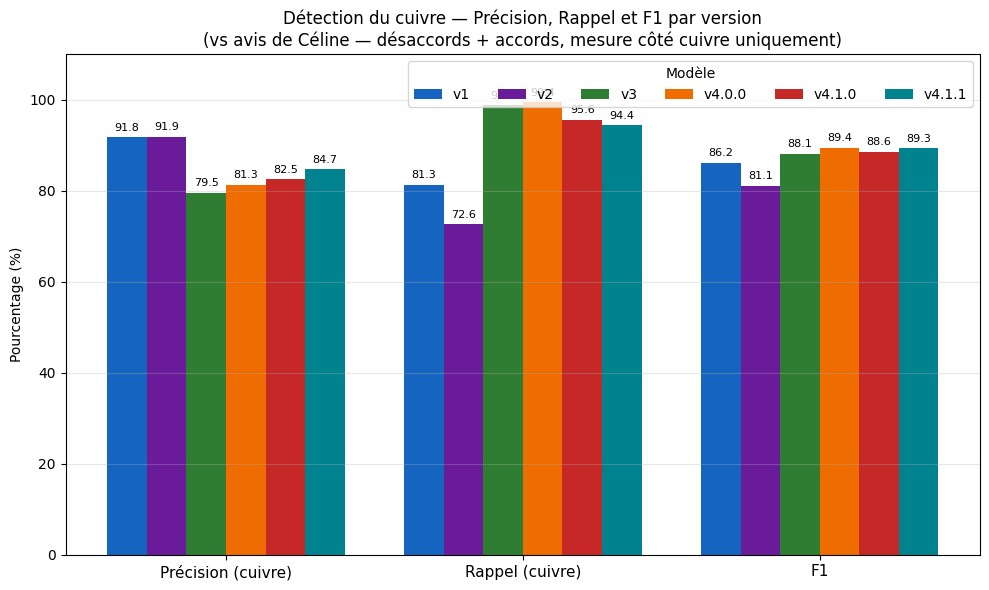

✓ Graphique sauvegardé : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/resultats/Datavis/metriques_v1v2v3v4.png


In [23]:
# ── Graphique — Précision / Rappel / F1 par version (v1 à v4.1.1) ──
# Rappel : "Précision"/"Rappel" ci-dessous concernent uniquement la classe
# cuivre, mesurée sur ce que Céline a validé (désaccords + accords) — voir
# la note détaillée dans la cellule précédente.
import matplotlib.pyplot as plt
import numpy as np

DOSSIER_VIZ = os.path.join(RACINE, "resultats", "Datavis")
os.makedirs(DOSSIER_VIZ, exist_ok=True)

colonnes  = ["Précision_cuivre_sur_avis_celine", "Rappel_cuivre_sur_avis_celine", "F1"]
etiquettes = ["Précision (cuivre)", "Rappel (cuivre)", "F1"]
versions  = recap_v4["Version"].tolist()
x = np.arange(len(colonnes))
largeur = 0.8 / len(versions)
couleurs = {
    "v1": "#1565c0", "v2": "#6a1b9a", "v3": "#2e7d32",
    "v4.0.0": "#ef6c00", "v4.1.0": "#c62828", "v4.1.1": "#00838f",
}

fig, ax = plt.subplots(figsize=(10, 6))
for i, v in enumerate(versions):
    valeurs = [recap_v4.loc[recap_v4.Version == v, c].values[0] * 100 for c in colonnes]
    decalage = (i - (len(versions) - 1) / 2) * largeur
    barres = ax.bar(x + decalage, valeurs, largeur, label=v, color=couleurs.get(v, "#999"))
    for b, val in zip(barres, valeurs):
        ax.text(b.get_x() + b.get_width() / 2, val + 1, f"{val:.1f}",
                ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Pourcentage (%)")
ax.set_title("Détection du cuivre — Précision, Rappel et F1 par version\n"
              "(vs avis de Céline — désaccords + accords, mesure côté cuivre uniquement)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(etiquettes, fontsize=11)
ax.set_ylim(0, 110)
ax.legend(title="Modèle", ncol=len(versions))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

chemin_png = os.path.join(DOSSIER_VIZ, "metriques_v1v2v3v4.png")
plt.savefig(chemin_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Graphique sauvegardé : {chemin_png}")